## 1. Import Library
Mengimpor semua library yang dibutuhkan:
- `os`, `cv2`, `numpy`, `pandas` — utilitas umum untuk file, gambar, dan data
- `YOLO` (ultralytics) — model deteksi objek YOLOv8 untuk mendeteksi kerusakan mobil
- `sklearn` — untuk split data, encoding label, dan model Random Forest (prediksi harga)

In [1]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd

from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

## 2. Konfigurasi Path Dataset
Mendefinisikan path ke dataset gambar (beserta file `data.yaml` yang berisi konfigurasi kelas) dan dataset harga mobil (CSV). Kemudian memverifikasi bahwa kedua file tersebut ada, dan menampilkan isi `data.yaml` — termasuk 8 kelas kerusakan: *Broken part, Corrosion, Cracked, Dent, Flaking, Missing part, Paint chip, Scratch*.

In [2]:
IMG_DATASET_PATH = r"D:\mobil_project\img2_dataset"
YAML_PATH = os.path.join(IMG_DATASET_PATH, "data.yaml")

PRICE_DATASET_PATH = r"D:\mobil_project\prices_dataset\car_prices.csv"

print("YAML exists:", os.path.exists(YAML_PATH))
print("Price CSV exists:", os.path.exists(PRICE_DATASET_PATH))
print(open(YAML_PATH).read())

YAML exists: True
Price CSV exists: True
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['Broken part', 'Corrosion', 'Cracked', 'Dent', 'Flaking', 'Missing part', 'Paint chip', 'Scratch']

roboflow:
  workspace: bocils-workspace
  project: damage-car-lh7s3-dugbn
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/bocils-workspace/damage-car-lh7s3-dugbn/dataset/1


## 3. Training Model YOLOv8 (Deteksi Kerusakan)
Melatih model YOLOv8n dari bobot pretrained (`yolov8n.pt`) menggunakan dataset kerusakan mobil selama **50 epoch** dengan ukuran gambar 640×640 dan batch size 8. Hasil training (bobot terbaik) disimpan ke folder `runs/detect/damage_model_new`.

In [3]:
damage_model = YOLO("yolov8n.pt")

damage_model.train(
    data=YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=8,
    project=r"D:\mobil_project\runs\detect",
    name="damage_model_new"
)

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.237  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\mobil_project\img2_dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=damag

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C0CB7E80D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047

## 4. Mencari File Model (.pt) yang Tersimpan
Melakukan scan seluruh folder proyek untuk menemukan semua file bobot model (`.pt`) yang sudah tersimpan. Berguna untuk memastikan file hasil training tersedia sebelum dimuat.

In [8]:
import os

base = r"D:\mobil_project"

for root, dirs, files in os.walk(base):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

D:\mobil_project\yolo11n.pt
D:\mobil_project\yolov8n.pt
D:\mobil_project\runs\detect\damage_model_new2\weights\best.pt
D:\mobil_project\runs\detect\damage_model_new2\weights\last.pt
D:\mobil_project\runs\detect\train7\weights\best.pt
D:\mobil_project\runs\detect\train7\weights\last.pt


## 5. Memuat Model Terbaik
Memuat bobot terbaik hasil training (`best.pt`) dari model deteksi kerusakan ke dalam objek YOLO. Model ini siap digunakan untuk inferensi/prediksi.

In [10]:

DAMAGE_MODEL_PATH = r"D:\mobil_project\runs\detect\damage_model_new2\weights\best.pt"

damage_model = YOLO(DAMAGE_MODEL_PATH)

print(" Model loaded")

 Model loaded


## 6. Melihat Sampel Gambar Test
Menampilkan 5 nama file pertama dari folder gambar test untuk memverifikasi bahwa dataset test tersedia dan dapat diakses.

In [11]:
test_img = r"D:\mobil_project\img2_dataset\test\images"
print(os.listdir(test_img)[:5])

['Car-damages-1066_png.rf.5c89767271a36a53b3cc9027ebe7560b.jpg', 'Car-damages-106_png.rf.712d4f15358b5bd067f0d5b3218ff365.jpg', 'Car-damages-1071_png.rf.4ca8b24ece062bfe19dff2d9f44e6d45.jpg', 'Car-damages-1072_png.rf.9ec648c0def9aaa816f72d83b6d462d5.jpg', 'Car-damages-1075_png.rf.81064be2bce380a9319a46bd0ee13447.jpg']


## 7. Inferensi pada Gambar Test
Menjalankan model deteksi kerusakan pada satu gambar contoh dari dataset test. Hasil deteksi (bounding box dan label kelas) ditampilkan langsung menggunakan `results[0].show()`. Ganti `NAMA_GAMBAR.jpg` dengan nama file gambar yang ingin diuji.

In [ ]:
img_path = r"D:\mobil_project\img2_dataset\test\images\NAMA_GAMBAR.jpg"

results = damage_model(img_path)

results[0].show()

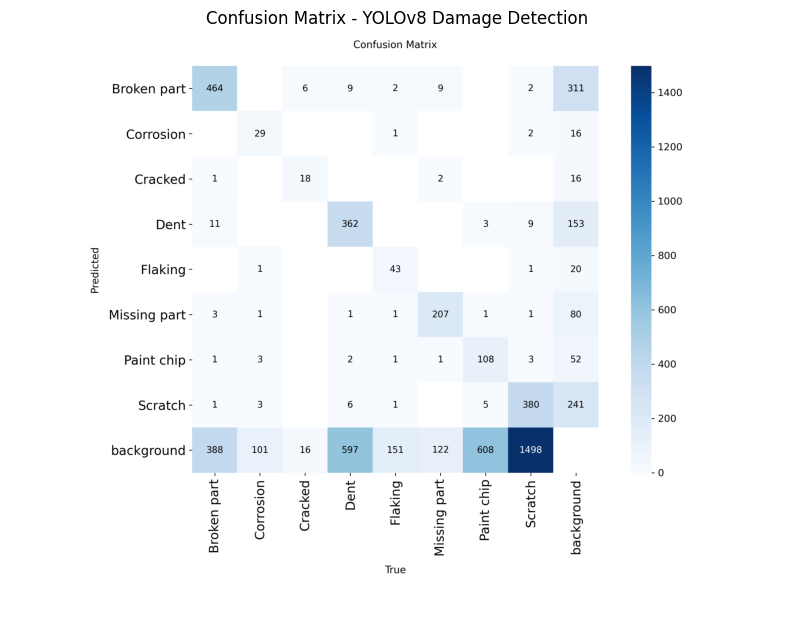

In [3]:

import matplotlib.pyplot as plt
import os

CONF_MATRIX_PATH = r"D:\mobil_project\runs\detect\damage_model_new2\confusion_matrix.png"


img = Image.open(CONF_MATRIX_PATH)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix - YOLOv8 Damage Detection")
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

RESULTS_CSV_PATH = r"D:\mobil_project\runs\detect\damage_model_new2\results.csv"

print("File exists:", os.path.exists(RESULTS_CSV_PATH))

df_results = pd.read_csv(RESULTS_CSV_PATH)

print(df_results.columns)
df_results.head()

File exists: True
Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,46.3727,1.72725,3.51562,1.47871,0.37448,0.11097,0.11712,0.08177,1.75745,2.69110,1.49085,0.000276,0.000276,0.000276
1,2,86.2092,1.68050,2.63708,1.41069,0.41065,0.15432,0.16115,0.11008,1.81526,2.45846,1.54170,0.000543,0.000543,0.000543
2,3,126.2990,1.67375,2.46166,1.41919,0.27786,0.21034,0.16940,0.10938,1.80709,2.31465,1.50946,0.000799,0.000799,0.000799
3,4,165.5750,1.68044,2.32702,1.40450,0.39813,0.22189,0.21108,0.14487,1.77146,2.19037,1.47318,0.000784,0.000784,0.000784
4,5,205.1390,1.61151,2.16758,1.37750,0.46551,0.23383,0.23817,0.15969,1.75970,2.13590,1.49322,0.000767,0.000767,0.000767


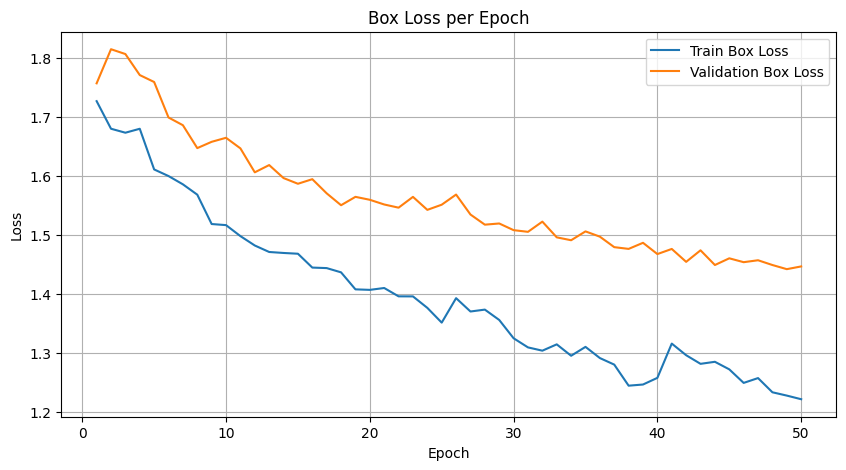

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df_results["epoch"], df_results["train/box_loss"], label="Train Box Loss")
plt.plot(df_results["epoch"], df_results["val/box_loss"], label="Validation Box Loss")

plt.title("Box Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

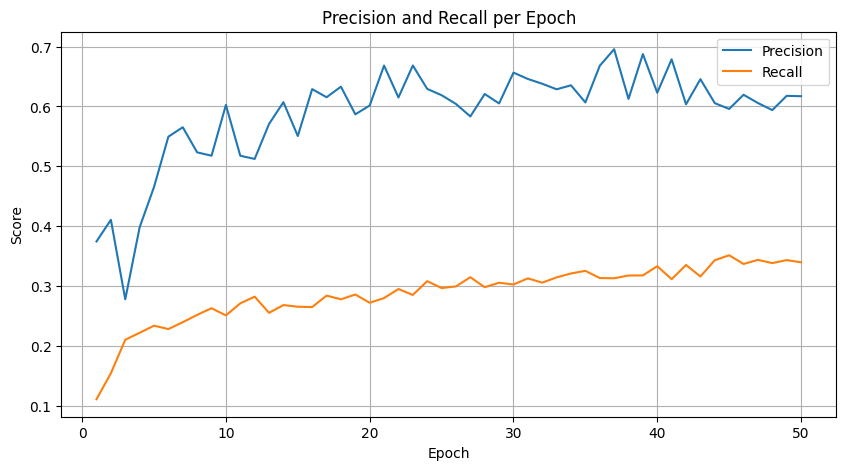

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df_results["epoch"], df_results["metrics/precision(B)"], label="Precision")
plt.plot(df_results["epoch"], df_results["metrics/recall(B)"], label="Recall")

plt.title("Precision and Recall per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()